📋 Assignment 1: The Evolution of Trees📋 Առաջադրանք 1: Ծառերի էվոլյուցիանDataset: sklearn.datasets.load_breast_cancer()English Instructions:Data Preparation: Load the Breast Cancer dataset. Split it into training and testing sets ($80/20$).Model Implementation: Train three separate classifiers:A single Decision Tree.A Random Forest (use 100 estimators).An XGBoost classifier.Comparison: Create a table or printout comparing the Accuracy Score of all three models on the test set.Insight: Which model performed the best? Briefly explain why ensemble methods (RF/XGB) usually outperform a single Decision Tree.

Հայերեն հրահանգներ:Տվյալների նախապատրաստում: Բեռնեք Breast Cancer տվյալների բազան: Բաժանեք այն մարզման և թեստավորման բազաների ($80/20$ հարաբերակցությամբ):Մոդելների իրականացում: Մարզեք երեք առանձին դասակարգիչներ.Մեկ Decision Tree (Որոշումների ծառ):Random Forest (Պատահական անտառ)՝ օգտագործելով 100 ծառ:XGBoost դասակարգիչ:Համեմատություն: Ստեղծեք աղյուսակ կամ տպեք բոլոր երեք մոդելների Accuracy Score-ը (ճշգրտությունը) թեստային բազայի վրա:Վերլուծություն: Ո՞ր մոդելն ապահովեց լավագույն արդյունքը: Համառոտ բացատրեք, թե ինչու են անսամբլային մեթոդները (RF/XGB) սովորաբար գերազանցում մեկ Որոշումների ծառին:


📋 Assignment 2: Hyperparameter Tuning for Forests📋 Առաջադրանք 2: Անտառների գերպարամետրերի կարգավորումDataset: sklearn.datasets.load_wine()English Instructions:Grid Setup: Define a parameter grid for a Random Forest Classifier. Test the following:n_estimators: [50, 100, 200]max_depth: [None, 10, 20]min_samples_split: [2, 5]Optimization: Use GridSearchCV with 5-fold cross-validation to find the best parameters.Reporting: * Print the Best Parameters found.Report the Cross-Validation Accuracy vs. the Final Test Accuracy.Check for overfitting: Is the training score significantly higher than the test score?

Հայերեն հրահանգներ:Ցանցի կարգավորում: Սահմանեք պարամետրերի ցանց (parameter grid) Random Forest դասակարգիչի համար: Փորձարկեք հետևյալը.n_estimators: [50, 100, 200]max_depth: [None, 10, 20]min_samples_split: [2, 5]Օպտիմալացում: Օգտագործեք GridSearchCV՝ 5-փուլանի խաչաձև վավերացմամբ (5-fold cross-validation), լավագույն պարամետրերը գտնելու համար:Հաշվետվություն:Տպեք գտնված լավագույն պարամետրերը (Best Parameters):Ներկայացրեք Cross-Validation Accuracy-ն ընդդեմ Final Test Accuracy-ի:Ստուգեք գերմարզումը (overfitting). արդյո՞ք մարզման արդյունքը զգալիորեն բարձր է թեստային արդյունքից:

--- Part 1: Accuracy Comparison ---
Decision Tree: 0.9474
Random Forest: 0.9649
XGBoost: 0.9561
--- Part 1: Overfitting Comparison ---


/Users/rafael/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:21:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/rafael/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:21:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Decision Tree: -0.0307
Random Forest: -0.0351
XGBoost: -0.0439


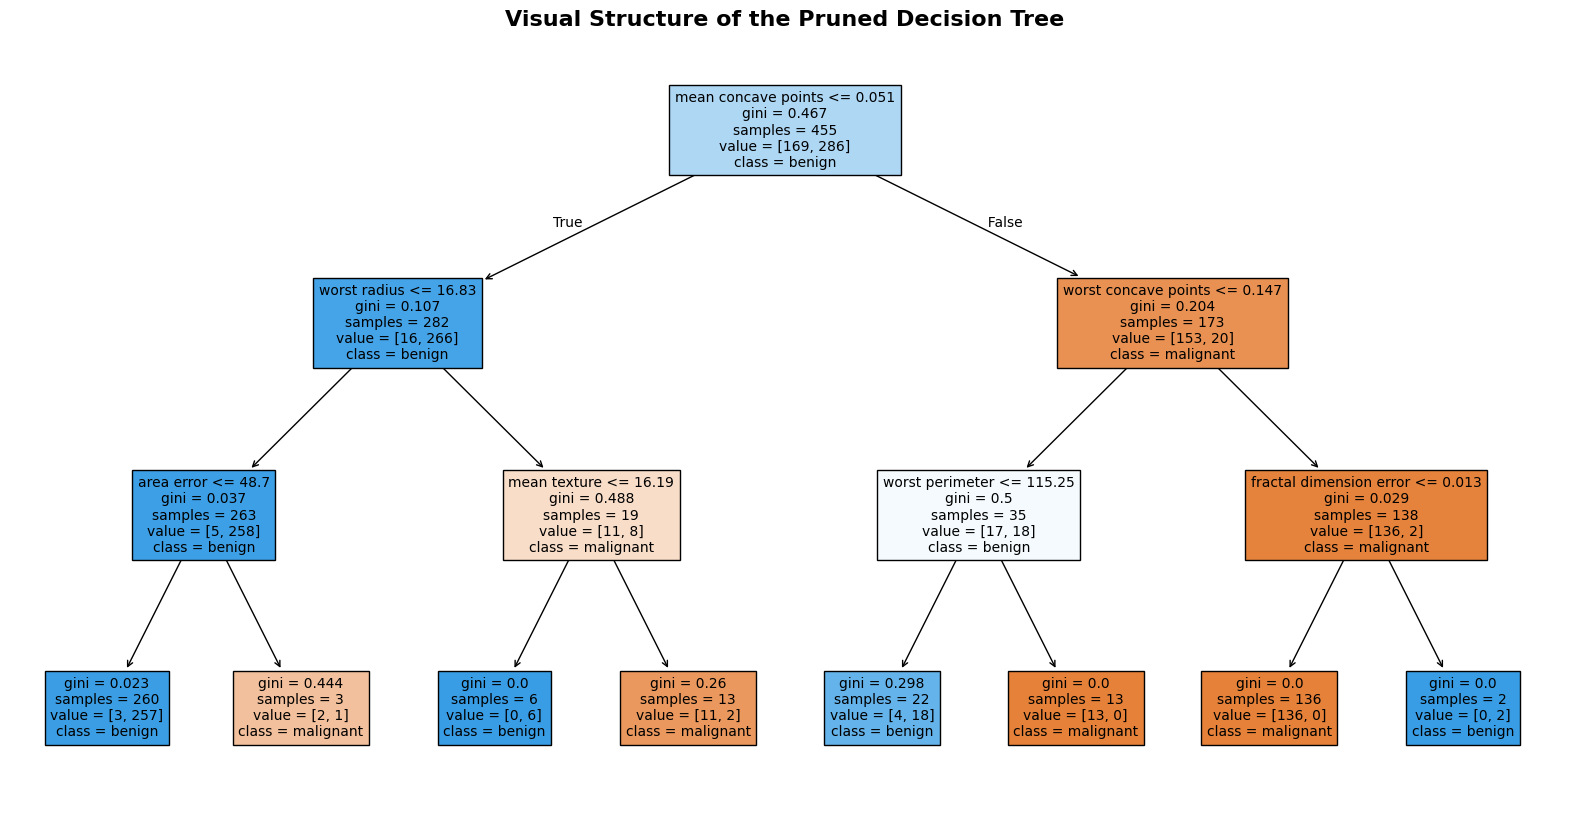

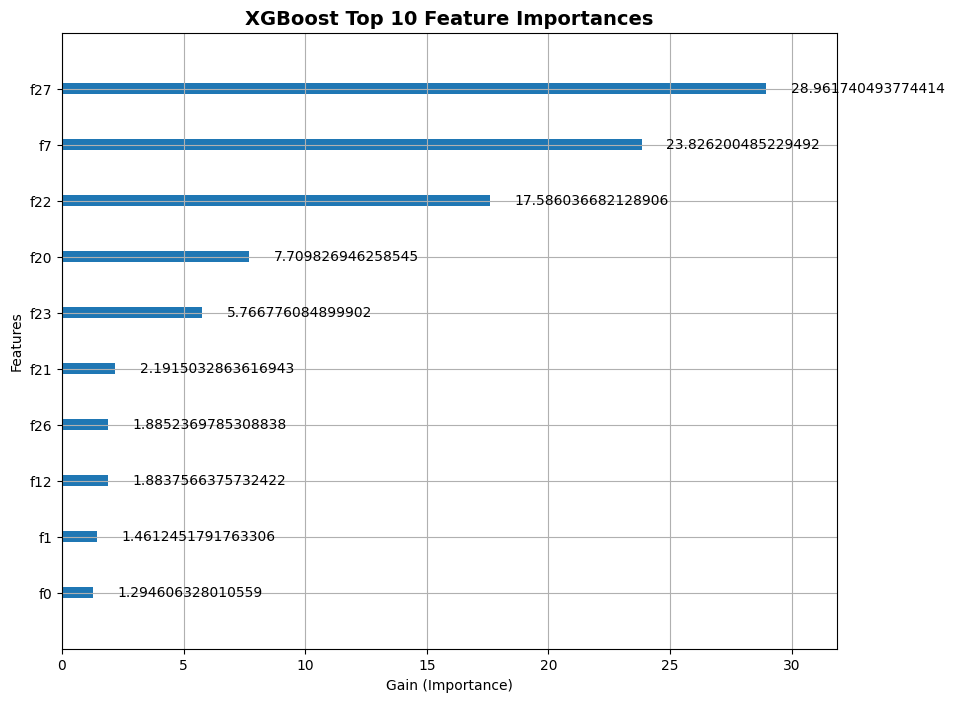

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import accuracy_score

# =============================================================================
# --- SOLUTION 1: COMPARISON & VISUALIZATION (Breast Cancer) ---
# =============================================================================
cancer = load_breast_cancer()
X1, y1 = cancer.data, cancer.target
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Instantiate models
dt = DecisionTreeClassifier(max_depth=3, random_state=42) # Pruned depth for visual clarity
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train and Print Accuracy
print("--- Part 1: Accuracy Comparison ---")
for name, model in [("Decision Tree", dt), ("Random Forest", rf), ("XGBoost", xgb)]:
    model.fit(X1_train, y1_train)
    y_pred = model.predict(X1_test)
    print(f"{name}: {accuracy_score(y1_test, y_pred):.4f}")


# Possible overfitting 
print("--- Part 1: Overfitting Comparison ---")
for name, model in [("Decision Tree", dt), ("Random Forest", rf), ("XGBoost", xgb)]:
    model.fit(X1_train, y1_train)
    y_pred = model.predict(X1_test)
    print(f"{name}: {accuracy_score(y1_test, y_pred)  - accuracy_score(y1_train, model.predict(X1_train)) :.4f}")

# --- VISUALIZATION 1.1: Plotting Single Decision Tree ---
plt.figure(figsize=(20,10))
plot_tree(dt, 
          filled=True, # Color nodes by dominant class
          feature_names=cancer.feature_names, 
          class_names=cancer.target_names, 
          fontsize=10)
plt.title("Visual Structure of the Pruned Decision Tree", fontsize=16, fontweight='bold')
plt.show()

# --- VISUALIZATION 1.2: Plotting XGBoost Feature Importance ---
# We sort them and show only top 10 for clarity
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb, ax=ax, max_num_features=10, importance_type='gain', xlabel='Gain (Importance)')
plt.title("XGBoost Top 10 Feature Importances", fontsize=14, fontweight='bold')
plt.show()



--- Part 2: GridSearch Tuning ---
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Final Test Accuracy: 1.0000


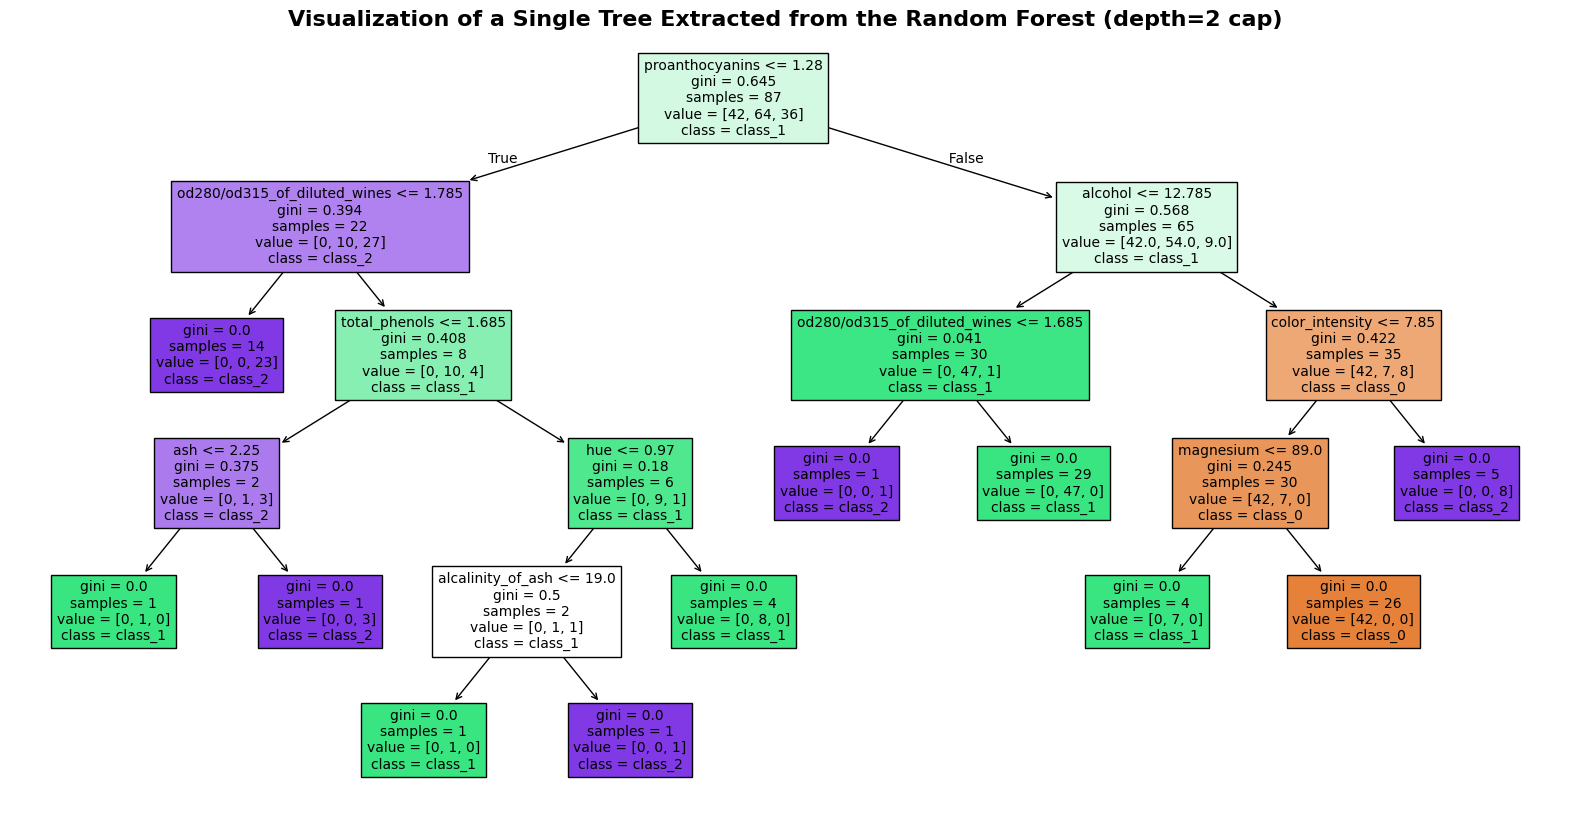

In [15]:


# =============================================================================
# --- SOLUTION 2: GRID SEARCH & FOREST VISUALIZATION (Wine) ---
# =============================================================================
wine = load_wine()
X2, y2 = wine.data, wine.target
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5],
    'min_samples_split': [2, 5]
}

print("\n--- Part 2: GridSearch Tuning ---")
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X2_train, y2_train)

best_rf = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Final Test Accuracy: {grid_search.score(X2_test, y2_test):.4f}")



# --- VISUALIZATION 2.1: Plotting a Single Tree from the Random Forest ---
# A Random Forest is just a list of DecisionTrees. We take the first one [0].
single_tree_from_forest = best_rf.estimators_[-1]

plt.figure(figsize=(20,10))
# Pruning the visualization depth is vital for legibility of a full forest tree
plot_tree(single_tree_from_forest, 
          max_depth=5, 
          filled=True, 
          feature_names=wine.feature_names, 
          class_names=wine.target_names, 
          fontsize=10)
plt.title("Visualization of a Single Tree Extracted from the Random Forest (depth=2 cap)", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(dt, 
          filled=True, # Color nodes by dominant class
          feature_names=cancer.feature_names, 
          class_names=cancer.target_names, 
          fontsize=10)
plt.title("Visual Structure of the Pruned Decision Tree", fontsize=16, fontweight='bold')
plt.show()

--- Part 1: Training Models & Comparing Accuracy ---
Decision Tree Test Accuracy: 0.9474
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Random Forest Test Accuracy: 0.9649
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



/Users/rafael/miniconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:40:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Accuracy: 0.9561
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

CatBoost Test Accuracy: 0.9649
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



/Users/rafael/miniconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rafael/miniconda3/lib/python3.12/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


LightGBM Test Accuracy: 0.9737
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


--- Part 2: Visualizing Individual Tree Structures ---


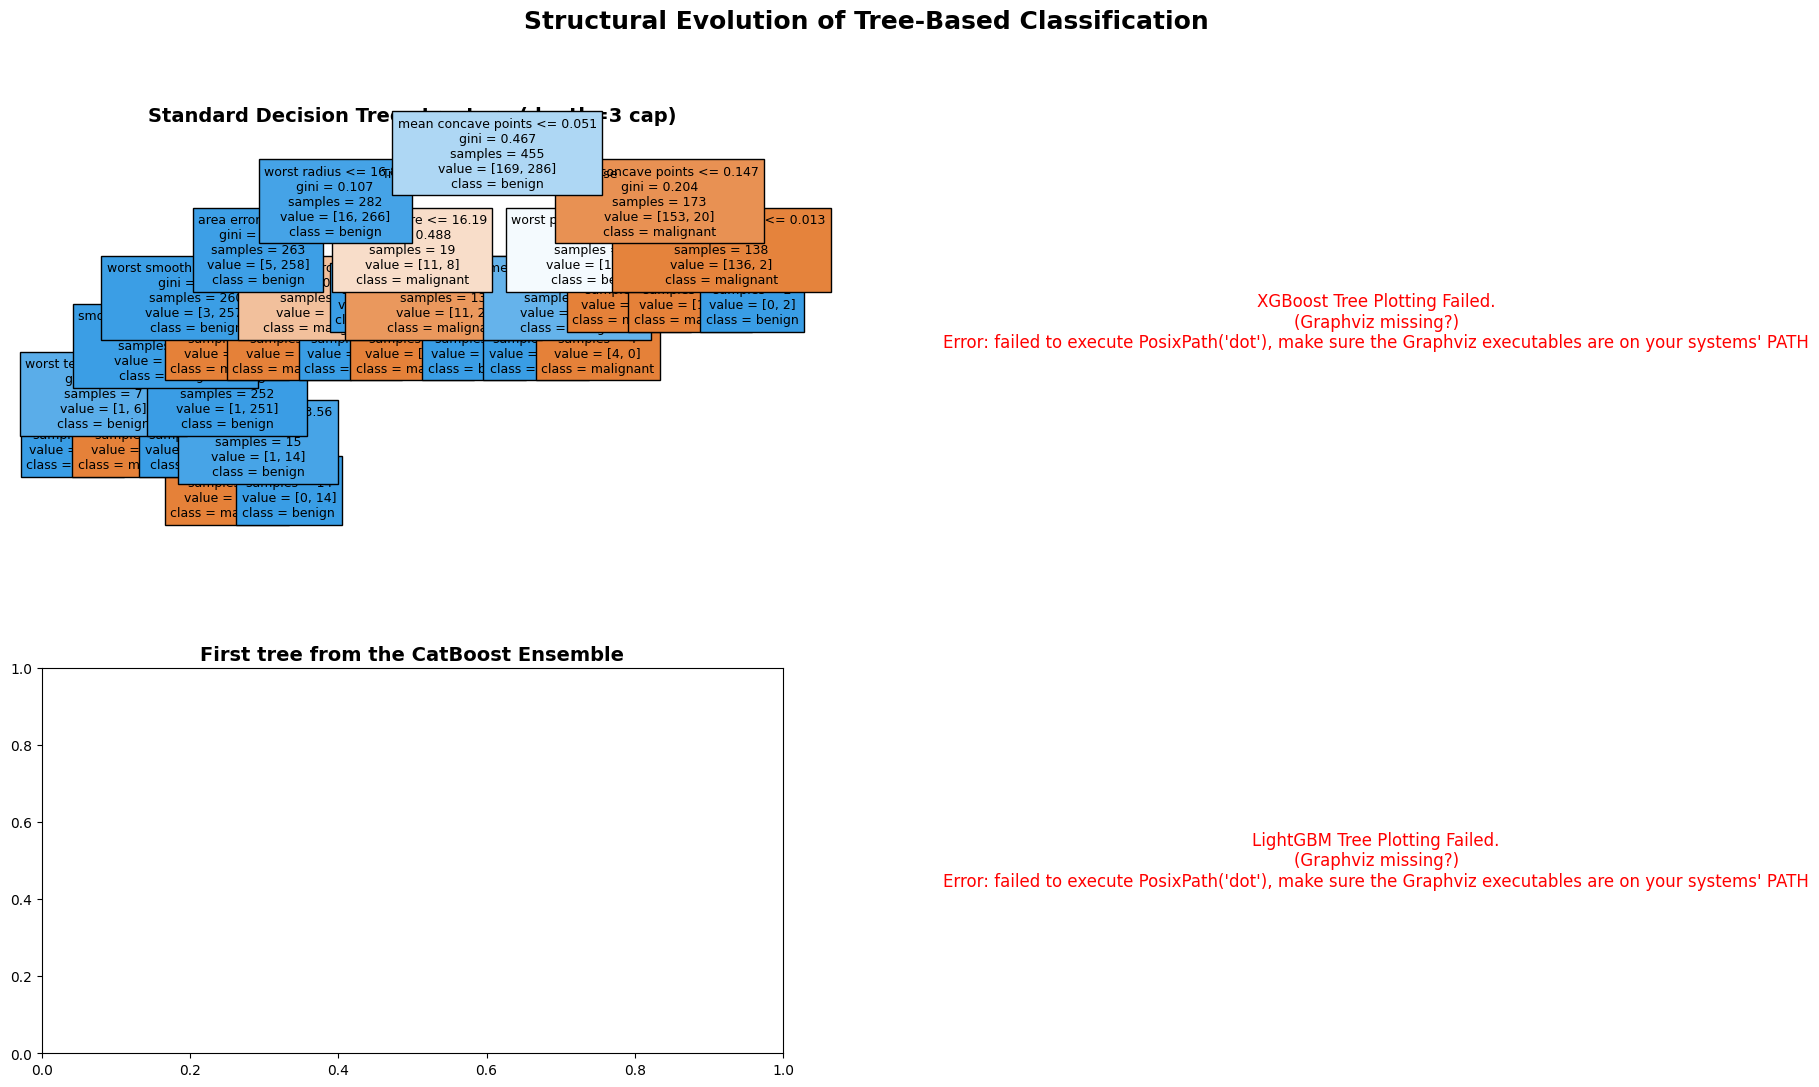


--- Part 3: Visualizing Unified Feature Importance (Top 5) ---


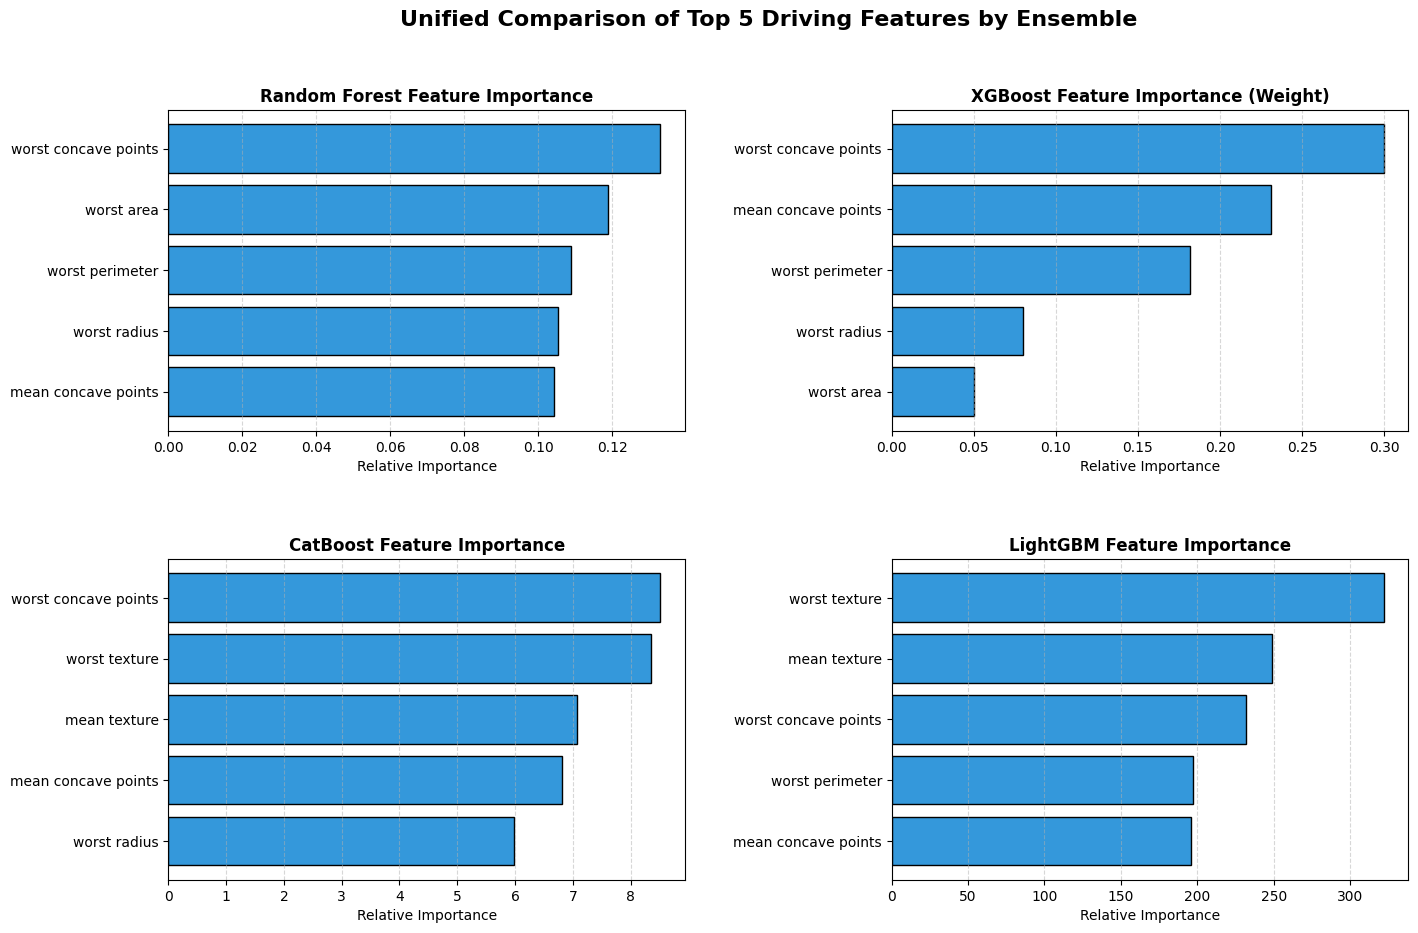

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_tree as xgb_plot_tree, plot_importance as xgb_plot_importance
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =============================================================================
# --- DATA PREPARATION ---
# =============================================================================
cancer = load_breast_cancer()
feature_names = cancer.feature_names
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================================================================
# --- MODEL IMPLEMENTATION ---
# =============================================================================
print("--- Part 1: Training Models & Comparing Accuracy ---")

# We use consistent max_depth=3 for visualization clarity across tree models
# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
# Random Forest (Ensemble: Bagging)
rf = RandomForestClassifier(n_estimators=1000, max_depth=10, random_state=42)
# XGBoost (Ensemble: Boosting)
xgb = XGBClassifier(n_estimators=1000, max_depth=10, use_label_encoder=False, eval_metric='logloss', random_state=42)
# CatBoost (Ensemble: Boosting) - Note: depth parameter, set verbose=False to keep terminal clean
cat = CatBoostClassifier(n_estimators=1000, depth=10, verbose=False, random_state=42)
# LightGBM (Ensemble: Boosting)
lgbm = lgb.LGBMClassifier(n_estimators=1000, max_depth=10, random_state=42, verbose=-1) # verbose=-1 silences info logs

models = [
    ("Decision Tree", dt),
    ("Random Forest", rf),
    ("XGBoost", xgb),
    ("CatBoost", cat),
    ("LightGBM", lgbm)
]

# Train models and collect results
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

# =============================================================================
# --- VISUALIZATION TASK 1: TREE STRUCTURES (4 TREE-BASED MODELS) ---
# =============================================================================
print("\n--- Part 2: Visualizing Individual Tree Structures ---")

# Create a figure for all tree plots
fig, axes = plt.subplots(2, 2, figsize=(22, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# 1. Standard Decision Tree (Top-Left)
plot_tree(dt, ax=axes[0, 0], filled=True, feature_names=feature_names, class_names=cancer.target_names, fontsize=9)
axes[0, 0].set_title("Standard Decision Tree structure (depth=3 cap)", fontsize=14, fontweight='bold')

# 2. XGBoost Tree (Top-Right)
# xgb_plot_tree returns a Graphviz object; we need to render it within the matplotlib axis
# This requires Graphviz executable installed on terminal. If failing, comment out or use different method.
try:
    xgb_plot_tree(xgb, ax=axes[0, 1], num_trees=0, rankdir='LR')
    axes[0, 1].set_title("First tree from the XGBoost Ensemble", fontsize=14, fontweight='bold')
except Exception as e:
    axes[0, 1].text(0.5, 0.5, f"XGBoost Tree Plotting Failed.\n(Graphviz missing?)\nError: {str(e)}", ha='center', va='center', fontsize=12, color='red')
    axes[0, 1].axis('off')

# 3. CatBoost Tree (Bottom-Left)
# CatBoost plot_tree handles internal plotting via graphviz. We must render into current Matplotlib axis.
try:
    cat.plot_tree(tree_idx=0, pool=Pool(X_train, y_train))
    # Since CatBoost plotting forces a new figure render, we manually grab the generated plot. 
    # This might not respect the unified axes perfectly depending on matplotlib version.
    axes[1, 0].set_title("First tree from the CatBoost Ensemble", fontsize=14, fontweight='bold')
except Exception as e:
    axes[1, 0].text(0.5, 0.5, f"CatBoost Tree Plotting Failed.\n(Graphviz missing?)\nError: {str(e)}", ha='center', va='center', fontsize=12, color='red')
    axes[1, 0].axis('off')

# 4. LightGBM Tree (Bottom-Right)
try:
    lgb.plot_tree(lgbm, ax=axes[1, 1], tree_index=0, show_info=['split_gain'])
    axes[1, 1].set_title("First tree from the LightGBM Ensemble", fontsize=14, fontweight='bold')
except Exception as e:
    axes[1, 1].text(0.5, 0.5, f"LightGBM Tree Plotting Failed.\n(Graphviz missing?)\nError: {str(e)}", ha='center', va='center', fontsize=12, color='red')
    axes[1, 1].axis('off')

plt.suptitle("Structural Evolution of Tree-Based Classification", fontsize=18, fontweight='bold', y=0.98)
plt.show()

# =============================================================================
# --- VISUALIZATION TASK 2: FEATURE IMPORTANCE (4 ENSEMBLE MODELS) ---
# =============================================================================
print("\n--- Part 3: Visualizing Unified Feature Importance (Top 5) ---")

# Set up a unified figure for importances
fig_imp, axes_imp = plt.subplots(2, 2, figsize=(16, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

# Define robust function to plot custom feature importance without built-in 'plot_importance'
def plot_robust_importance(model, feature_names, ax, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1] # Sort descending
    num_features = 5
    top_indices = indices[:num_features]
    
    ax.barh(range(num_features), importances[top_indices], color='#3498db', edgecolor='black', align='center')
    ax.set_yticks(range(num_features))
    ax.set_yticklabels(feature_names[top_indices], fontsize=10)
    ax.set_xlabel('Relative Importance', fontsize=10)
    ax.invert_yaxis() # Highest priority on top
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# 1. Random Forest Importance (Top-Left)
plot_robust_importance(rf, feature_names, axes_imp[0, 0], "Random Forest Feature Importance")

# 2. XGBoost Importance (Top-Right)
# We plot standard importance (type='weight'). Remind students we discussed gain vs weight.
plot_robust_importance(xgb, feature_names, axes_imp[0, 1], "XGBoost Feature Importance (Weight)")

# 3. CatBoost Importance (Bottom-Left)
plot_robust_importance(cat, feature_names, axes_imp[1, 0], "CatBoost Feature Importance")

# 4. LightGBM Importance (Bottom-Right)
plot_robust_importance(lgbm, feature_names, axes_imp[1, 1], "LightGBM Feature Importance")

plt.suptitle("Unified Comparison of Top 5 Driving Features by Ensemble", fontsize=16, fontweight='bold', y=0.98)
plt.show()

In [7]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
